# Ship Detection from Drive

## 1. Config

In [1]:
import os

CFG = dict(
    MODEL_PATH = "/kaggle/input/models/hunglq/pretrained/pytorch/default/1/yolo11s_tci.pt",  
    HF_FALLBACK_REPO = "mayrajeo/marine-vessel-yolo",
    HF_FALLBACK_FILE = "yolo11s_tci.pt",
    DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/12QVIJ3H4_h_YeKHEJ8U2387wuMKRd4Qz",  # <<< SỬA
    LIMIT = None,   
    TILE = 320,
    OVERLAP = 64,
    IMGSZ = 320,
    CONF = 0.1,
    IOU_NMS = 0.7,
    NMS_IOU = 0.5,
    BATCH = 16,
    SKIP_DARK = 5,
    DEVICE = "auto",

    SAVE_GEOTIFF = True,
    SAVE_JP2 = False,
    SAVE_VECTOR = True,
    BURN_MAX_MP = 400,
    OVERVIEW_MAX = 1600,
    LINE_THICKNESS = 1,
    DRAW_GT = False,
    EXPORT_MODE = "both", # pred | gt | both
    GT_GPKG_PATH = "/kaggle/input/zenodo-vessel-gpkg",
    GT_LAYER = None,
    DL_DIR = "/kaggle/working/drive_tci",    
    OUT_DIR = "/kaggle/working/drive_infer",
)
os.makedirs(CFG["DL_DIR"], exist_ok=True)
os.makedirs(CFG["OUT_DIR"], exist_ok=True)
print("Confidence threshold:", CFG["CONF"])

Confidence threshold: 0.1


## 2. Ultralytics for YOLO

In [2]:
%pip install -q -U ultralytics "huggingface_hub>=0.24" rasterio geopandas gdown

import ultralytics
ultralytics.checks()
print("ultralytics:", ultralytics.__version__)
import rasterio, geopandas
_jp2 = rasterio.drivers.raster_driver_extensions().get("jp2", "")

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)
ultralytics: 8.4.112


In [3]:
import torch

def pick_device(pref):
    if pref not in ("auto", None, ""):
        print("device preference:", pref)
        return str(pref)
    if not torch.cuda.is_available():
        print("cuda not available")
        return "cpu"
    try:
        _ = (torch.zeros(16, device="cuda") + 1).sum().item()
        torch.cuda.synchronize()
        print("gpu detected:", torch.cuda.get_device_name(0))
        return "0"
    except Exception as e:
        print("Not found GPU kernel:", str(e).splitlines()[0])
        return "cpu"

DEVICE_EFF = pick_device(CFG["DEVICE"])
print("device used =", DEVICE_EFF)

gpu detected: Tesla T4
device used = 0


## 3. Apply model

In [4]:
from ultralytics import YOLO

def resolve_model(cfg):
    p = cfg["MODEL_PATH"]
    if p and os.path.exists(p):
        print("Used model:", p)
        return p
    from huggingface_hub import hf_hub_download
    return hf_hub_download(repo_id=cfg["HF_FALLBACK_REPO"], filename=cfg["HF_FALLBACK_FILE"],
                           local_dir="/kaggle/working/weights")

MODEL_WEIGHTS = resolve_model(CFG)
model = YOLO(MODEL_WEIGHTS)

Used model: /kaggle/input/models/hunglq/pretrained/pytorch/default/1/yolo11s_tci.pt


## 4. Inference, Output

In [5]:
import os, json as _json
import numpy as np
import rasterio
from rasterio.windows import Window
from PIL import Image
import torch
from torchvision.ops import nms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import cv2
import geopandas as gpd
from shapely.geometry import box as shp_box


def _band_idx(nbands):
    return [1, 2, 3] if nbands >= 3 else [1, 1, 1]


def _to_uint8(arr):
    if arr.dtype == np.uint8:
        return arr
    a = arr.astype(np.float32)
    return np.clip(a / (float(a.max()) or 1.0) * 255.0, 0, 255).astype(np.uint8)


def _read_rgb_window(src, window):
    arr = src.read(indexes=_band_idx(src.count), window=window, boundless=True, fill_value=0)
    return _to_uint8(np.transpose(arr, (1, 2, 0)))


def _tile_offsets(size, tile, stride):
    if size <= tile:
        return [0]
    offs = list(range(0, size - tile + 1, stride))
    if offs[-1] != size - tile:
        offs.append(size - tile)
    return offs


def infer_large_raster(raster_path, model, conf=0.25, tile=320, overlap=64, imgsz=320, iou_nms=0.7, nms_iou=0.5, batch=16, skip_dark=5, device="cpu", verbose=True):

    with rasterio.open(raster_path) as src:
        W, H, nb = src.width, src.height, src.count
        stride = max(1, tile - overlap)
        xs, ys = _tile_offsets(W, tile, stride), _tile_offsets(H, tile, stride)
        if verbose:
            print(f"Image info: {W}×{H}px, {nb} band -> {len(xs)}×{len(ys)} = {len(xs) * len(ys)} tile "
                  f"(tile={tile}, overlap={overlap}, imgsz={imgsz}).")

        boxes_all, scores_all = [], []
        buf_imgs, buf_off = [], []

        def _flush():
            if not buf_imgs:
                return
            for res, (ox, oy) in zip(
                    model.predict(buf_imgs, imgsz=imgsz, conf=conf, iou=iou_nms,
                                  device=device, verbose=False), buf_off):
                if res.boxes is None or len(res.boxes) == 0:
                    continue
                xyxy = res.boxes.xyxy.cpu().numpy().copy()
                xyxy[:, [0, 2]] += ox        # tile coordinate
                xyxy[:, [1, 3]] += oy
                boxes_all.append(xyxy)
                scores_all.append(res.boxes.conf.cpu().numpy())
            buf_imgs.clear(); buf_off.clear()

        n_used = 0
        for oy in ys:
            for ox in xs:
                arr = _read_rgb_window(src, Window(ox, oy, tile, tile))
                if int(arr.max()) < skip_dark:
                    continue
                buf_imgs.append(Image.fromarray(arr)); buf_off.append((ox, oy)); n_used += 1
                if len(buf_imgs) >= batch:
                    _flush()
        _flush()

    if verbose:
        print(f"Found {n_used} tile above dark threshold")
    if not boxes_all:
        return np.zeros((0, 4), np.float32), np.zeros((0,), np.float32), (W, H)

    boxes = np.concatenate(boxes_all).astype(np.float32)
    scores = np.concatenate(scores_all).astype(np.float32)
    keep = nms(torch.from_numpy(boxes), torch.from_numpy(scores), nms_iou).numpy()
    return boxes[keep], scores[keep], (W, H)


def draw_overview(raster_path, boxes=None, gt_boxes=None, max_side=1600, title=None, save_path=None, show=True, show_pred=None):
    # draw ground truth
    show_pred = (boxes is not None) if show_pred is None else show_pred
    boxes = np.zeros((0, 4), np.float32) if boxes is None else np.asarray(boxes)
    with rasterio.open(raster_path) as src:
        W, H = src.width, src.height
        scale = min(1.0, max_side / max(W, H))
        ow, oh = max(1, int(W * scale)), max(1, int(H * scale))
        ov = _to_uint8(np.transpose(
            src.read(indexes=_band_idx(src.count), out_shape=(3, oh, ow)), (1, 2, 0)))
    fig, ax = plt.subplots(figsize=(13, max(3, 13 * oh / ow)))
    ax.imshow(ov)
    if gt_boxes is not None and len(gt_boxes):
        for (x1, y1, x2, y2) in (np.asarray(gt_boxes) * scale):
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                           fill=False, edgecolor="lime", linewidth=1.0))
    for (x1, y1, x2, y2) in (np.asarray(boxes) * scale):
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor="red", linewidth=0.8))
    handles = []
    if show_pred:
        handles.append(Line2D([0], [0], color="red", lw=2, label="Dự đoán"))
    if gt_boxes is not None and len(gt_boxes):
        handles.append(Line2D([0], [0], color="lime", lw=2, label="Ground truth"))
    if handles:
        ax.legend(handles=handles, loc="upper right", fontsize=9)
    ax.set_title(title or f"{os.path.basename(raster_path)} — {len(boxes)} dự đoán", fontsize=12)
    ax.axis("off")
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show() if show else plt.close(fig)


def show_detection_crops(raster_path, boxes, scores, topk=12, pad=40, ncol=4, save_path=None, show=True):
    # show clear vessel
    if len(boxes) == 0:
        print("No vessel")
        return
    order = np.argsort(-scores)[:topk]
    with rasterio.open(raster_path) as src:
        W, H = src.width, src.height
        nrow = (len(order) + ncol - 1) // ncol
        fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
        axes = np.atleast_1d(axes).flatten()
        for ax, i in zip(axes, order):
            x1, y1, x2, y2 = boxes[i]
            cx0, cy0 = max(0, int(x1) - pad), max(0, int(y1) - pad)
            cw = min(W - cx0, int(x2 - x1) + 2 * pad)
            ch = min(H - cy0, int(y2 - y1) + 2 * pad)
            ax.imshow(_read_rgb_window(src, Window(cx0, cy0, cw, ch)))
            ax.add_patch(patches.Rectangle((x1 - cx0, y1 - cy0), x2 - x1, y2 - y1,
                                           fill=False, edgecolor="red", linewidth=1.0))
            ax.set_title(f"conf={scores[i]:.2f}", fontsize=9); ax.axis("off")
        for ax in axes[len(order):]:
            ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show() if show else plt.close(fig)


def burn_boxes_to_raster(raster_path, out_path, pred_boxes, pred_scores=None, gt_boxes=None, driver="GTiff", thickness=None, jp2_quality=100, max_megapixels=400):

    with rasterio.open(raster_path) as src:
        W, H = src.width, src.height
        mp = W * H / 1e6
        if mp > max_megapixels:
            raise MemoryError("Out of memory")
        img = np.ascontiguousarray(_read_rgb_window(src, Window(0, 0, W, H)))  # (H, W, 3) RGB uint8
        crs, transform = src.crs, src.transform

    t = max(1, int(thickness)) if thickness else 2

    def _draw(boxes, color):
        if boxes is None:
            return
        for b in np.asarray(boxes):
            x1, y1, x2, y2 = (int(round(v)) for v in b[:4])
            cv2.rectangle(img, (x1, y1), (x2, y2), color, t)

    _draw(gt_boxes, (0, 255, 0))
    _draw(pred_boxes, (255, 0, 0))

    profile = dict(driver=driver, width=W, height=H, count=3, dtype="uint8",
                   crs=crs, transform=transform)
    if driver == "GTiff":
        profile.update(compress="LZW", tiled=True, blockxsize=512, blockysize=512,
                       photometric="RGB", BIGTIFF="IF_SAFER")
    elif driver == "JP2OpenJPEG":
        profile.update(QUALITY=jp2_quality, REVERSIBLE=("YES" if jp2_quality >= 100 else "NO"))
    with rasterio.open(out_path, "w", **profile) as dst:
        for k in range(3):
            dst.write(img[:, :, k], k + 1)
    print(f"Written to: {out_path}")
    return out_path


def detections_to_vectors(raster_path, boxes, scores, out_geojson=None, out_gpkg=None):
    # Convert to georef, keep pixel info

    with rasterio.open(raster_path) as src:
        T, crs = src.transform, src.crs
    geoms, confs = [], []
    for (x1, y1, x2, y2), s in zip(boxes.tolist(), scores.tolist()):
        (X1, Y1) = rasterio.transform.xy(T, y1, x1)   # (row=y, col=x) -> (x_crs, y_crs)
        (X2, Y2) = rasterio.transform.xy(T, y2, x2)
        geoms.append(shp_box(min(X1, X2), min(Y1, Y2), max(X1, X2), max(Y1, Y2)))
        confs.append(round(float(s), 4))
    gdf = gpd.GeoDataFrame({"confidence": confs, "class": "vessel"}, geometry=geoms, crs=crs)
    if out_gpkg:
        gdf.to_file(out_gpkg, driver="GPKG")
        print("Vector gpkg", out_gpkg)
    if out_geojson:
        (gdf.to_crs(4326) if crs is not None else gdf).to_file(out_geojson, driver="GeoJSON")
        print("Geojson ", out_geojson)
    return gdf


def save_detections_json(raster_path, boxes, scores, out_json):
    crs, recs = None, []
    try:
        with rasterio.open(raster_path) as src:
            T, crs = src.transform, src.crs
            for (x1, y1, x2, y2), s in zip(boxes.tolist(), scores.tolist()):
                rec = {"confidence": round(float(s), 4),
                       "bbox_xyxy_pixel": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)]}
                if crs is not None:
                    gx, gy = rasterio.transform.xy(T, (y1 + y2) / 2.0, (x1 + x2) / 2.0)
                    rec["center_crs_xy"] = [round(gx, 2), round(gy, 2)]
                recs.append(rec)
    except Exception as e:
        recs = [{"confidence": round(float(s), 4),
                 "bbox_xyxy_pixel": [round(float(v), 1) for v in b]}
                for b, s in zip(boxes.tolist(), scores.tolist())]
    out = {"raster": os.path.basename(raster_path), "num_detections": len(recs),
           "crs": (str(crs) if crs is not None else None), "detections": recs}
    with open(out_json, "w") as f:
        _json.dump(out, f, indent=2)
    return out


def gt_to_vectors(raster_path, gt_boxes, out_geojson=None, out_gpkg=None):
    if gt_boxes is None or len(gt_boxes) == 0:
        return None
    with rasterio.open(raster_path) as src:
        T, crs = src.transform, src.crs
    geoms = []
    for (x1, y1, x2, y2) in np.asarray(gt_boxes, np.float32).tolist():
        (X1, Y1) = rasterio.transform.xy(T, y1, x1)   # (row=y, col=x) -> (x_crs, y_crs)
        (X2, Y2) = rasterio.transform.xy(T, y2, x2)
        geoms.append(shp_box(min(X1, X2), min(Y1, Y2), max(X1, X2), max(Y1, Y2)))
    gdf = gpd.GeoDataFrame({"class": "vessel"}, geometry=geoms, crs=crs)
    if out_gpkg:
        gdf.to_file(out_gpkg, driver="GPKG")
        print("GT GPKG", out_gpkg)
    if out_geojson:
        (gdf.to_crs(4326) if crs is not None else gdf).to_file(out_geojson, driver="GeoJSON")
        print("Vector", out_geojson)
    return gdf


def save_gt_json(raster_path, gt_boxes, out_json):
    crs, recs = None, []
    boxes = np.asarray(gt_boxes, np.float32).tolist() if gt_boxes is not None else []
    try:
        with rasterio.open(raster_path) as src:
            T, crs = src.transform, src.crs
            for (x1, y1, x2, y2) in boxes:
                rec = {"bbox_xyxy_pixel": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)]}
                if crs is not None:
                    gx, gy = rasterio.transform.xy(T, (y1 + y2) / 2.0, (x1 + x2) / 2.0)
                    rec["center_crs_xy"] = [round(gx, 2), round(gy, 2)]
                recs.append(rec)
    except Exception as e:
        recs = [{"bbox_xyxy_pixel": [round(float(v), 1) for v in b]} for b in boxes]
    out = {"raster": os.path.basename(raster_path), "num_gt": len(recs),
           "crs": (str(crs) if crs is not None else None), "ground_truth": recs}
    with open(out_json, "w") as f:
        _json.dump(out, f, indent=2)
    return out


def _list_layers(gpkg_path):
    # list layer in gpkg
    try:
        import pyogrio
        return [l[0] for l in pyogrio.list_layers(gpkg_path)]
    except Exception:
        pass
    try:
        import fiona
        return list(fiona.listlayers(gpkg_path))
    except Exception:
        return [None]


def inspect_gpkg(gpkg_path):
    import geopandas as gpd
    layers = _list_layers(gpkg_path)
    print("GeoPackage:", gpkg_path)
    print("layers: ", layers)
    for lyr in layers:
        g = gpd.read_file(gpkg_path, layer=lyr) if lyr else gpd.read_file(gpkg_path)
        print(f"\n== layer '{lyr}' == n={len(g)} | CRS={g.crs}")
        print("column:", list(g.columns))
        with_no_geom = [c for c in g.columns if c != g.geometry.name]
        if with_no_geom:
            print(g[with_no_geom].head(3).to_string())
    return layers


def load_gt_boxes_from_gpkg(gpkg_path, raster_path, product_col=None, product_value=None,
                            layer=None, verbose=True):
    gdf = gpd.read_file(gpkg_path, layer=layer) if layer else gpd.read_file(gpkg_path)
    if verbose:
        print(f"GT from gpkg: {len(gdf)} annotation | CRS={gdf.crs} | column={list(gdf.columns)}")
    if product_col and product_value is not None:
        assert product_col in gdf.columns, f"Not found '{product_col}'"
        m = gdf[product_col].astype(str).str.contains(str(product_value), case=False, na=False)
        gdf = gdf[m]
        if verbose:
            print(f"Filtered {product_col} = '{product_value}': {len(gdf)} annotation")
    with rasterio.open(raster_path) as src:
        crs, W, H = src.crs, src.width, src.height
        if crs is not None and gdf.crs is not None and str(gdf.crs) != str(crs):
            gdf = gdf.to_crs(crs)
        boxes = []
        for geom in gdf.geometry:
            if geom is None or geom.is_empty:
                continue
            minx, miny, maxx, maxy = geom.bounds
            r1, c1 = src.index(minx, maxy)    
            r2, c2 = src.index(maxx, miny)    
            x1, x2 = sorted((c1, c2)); y1, y2 = sorted((r1, r2))
            if x2 < 0 or y2 < 0 or x1 > W or y1 > H:
                continue
            boxes.append([max(0, x1), max(0, y1), min(W, x2), min(H, y2)])
    if verbose:
        print(f"-> {len(boxes)} GT in the image.")
    return np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), np.float32)


import re as _re
import glob as _glob


def parse_tile_date(name):
    # 'T34VEM_20220813T0959_TCI.jp2' -> ('34VEM', '20220813')."""
    base = os.path.basename(str(name))
    mt = _re.search(r"T?(\d{2}[A-Za-z]{3})", base)      # ô MGRS: 2 số + 3 chữ (vd 34VEM)
    md = _re.search(r"(?<!\d)(\d{8})(?!\d)", base)       # ngày YYYYMMDD
    return (mt.group(1).upper() if mt else None), (md.group(1) if md else None)


def _resolve_gpkg(gpkg_source, tile):
    if not os.path.isdir(gpkg_source):
        return gpkg_source
    cands = sorted(_glob.glob(os.path.join(gpkg_source, "*.gpkg")))
    if not tile:
        raise FileNotFoundError(f"File list: {[os.path.basename(c) for c in cands]}")
    for c in cands:
        stem = os.path.splitext(os.path.basename(c))[0].upper().lstrip("T")
        if stem == tile.upper().lstrip("T"):
            return c
    raise FileNotFoundError(f"Not found gpkg for '{tile}' in {gpkg_source}. ")


def _resolve_layer(gpkg, date, layer):
    if layer:
        return str(layer)
    lyrs = [str(l) for l in _list_layers(gpkg) if l]
    if date and date in lyrs:
        return date
    if len(lyrs) == 1:
        return lyrs[0]
    raise ValueError(
        f"'{os.path.basename(gpkg)}' has layers : {lyrs}. ")


def gt_boxes_for_raster(raster_path, gpkg_source, layer=None, verbose=True):
    tile, date = parse_tile_date(raster_path)
    gpkg = _resolve_gpkg(gpkg_source, tile)
    lyr = _resolve_layer(gpkg, date, layer)
    if verbose:
        print(f"GT: tile={tile} date={date} -> {os.path.basename(gpkg)} [layer '{lyr}']")
    return load_gt_boxes_from_gpkg(gpkg, raster_path, layer=lyr, verbose=verbose)


def _iou_matrix(A, B):
    if len(A) == 0 or len(B) == 0:
        return np.zeros((len(A), len(B)), np.float32)
    A = A[:, None, :]; B = B[None, :, :]
    ix1 = np.maximum(A[..., 0], B[..., 0]); iy1 = np.maximum(A[..., 1], B[..., 1])
    ix2 = np.minimum(A[..., 2], B[..., 2]); iy2 = np.minimum(A[..., 3], B[..., 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    aA = (A[..., 2] - A[..., 0]) * (A[..., 3] - A[..., 1])
    aB = (B[..., 2] - B[..., 0]) * (B[..., 3] - B[..., 1])
    return inter / (aA + aB - inter + 1e-9)


def _match(pred_boxes, pred_scores, gt_boxes, iou_thr):
    # calculate AP
    pb = np.asarray(pred_boxes, np.float32); ps = np.asarray(pred_scores, np.float32)
    gt = np.asarray(gt_boxes, np.float32)
    order = np.argsort(-ps)
    iou = _iou_matrix(pb[order], gt) if len(pb) else np.zeros((0, len(gt)))
    matched = np.zeros(len(gt), bool)
    tp = np.zeros(len(order), bool)
    for i in range(len(order)):
        if len(gt) == 0:
            break
        j = int(np.argmax(np.where(matched, -1.0, iou[i])))
        if iou[i, j] >= iou_thr and not matched[j]:
            tp[i] = True; matched[j] = True
    return ps[order], tp, len(gt)


def _average_precision(tp_desc, n_gt):
    if n_gt == 0:
        return float("nan")
    tp = np.cumsum(tp_desc.astype(np.float64))
    fp = np.cumsum((~tp_desc).astype(np.float64))
    recall = tp / (n_gt + 1e-9)
    precision = tp / np.maximum(tp + fp, 1e-9)
    ap = 0.0
    for r in np.linspace(0, 1, 101):
        p = precision[recall >= r].max() if np.any(recall >= r) else 0.0
        ap += p / 101.0
    return float(ap)


def evaluate_detections(pred_boxes, pred_scores, gt_boxes, conf=0.25, iou_thr=0.5):
    pb = np.asarray(pred_boxes, np.float32); ps = np.asarray(pred_scores, np.float32)
    n_gt = int(len(gt_boxes))

    sc, tp, _ = _match(pb, ps, gt_boxes, iou_thr)
    ap = _average_precision(tp, n_gt)
    maps = [_average_precision(_match(pb, ps, gt_boxes, t)[1], n_gt) for t in np.arange(0.5, 1.0, 0.05)]
    map5095 = float(np.nanmean(maps)) if n_gt else float("nan")

    keep = ps >= conf
    _, tp_c, _ = _match(pb[keep], ps[keep], gt_boxes, iou_thr)
    TP = int(tp_c.sum()); FP = int(len(tp_c) - TP); FN = int(n_gt - TP)
    P = TP / (TP + FP + 1e-9); R = TP / (TP + FN + 1e-9); F1 = 2 * P * R / (P + R + 1e-9)
    return {"conf": conf, "iou_thr": iou_thr, "n_pred": int(len(pb)), "n_gt": n_gt,
            "TP": TP, "FP": FP, "FN": FN,
            "precision": round(P, 4), "recall": round(R, 4), "f1": round(F1, 4),
            f"AP{int(iou_thr * 100)}": round(ap, 4), "mAP50_95": round(map5095, 4)}


print("Loaded helpers.py")

Loaded helpers.py


## 5. Download image from Drive

In [6]:
import gdown, glob

gdown.download_folder(CFG["DRIVE_FOLDER_URL"], output=CFG["DL_DIR"], quiet=False, use_cookies=False)

RASTER_EXTS = (".jp2", ".tif", ".tiff", ".png", ".jpg", ".jpeg")
raster_files = sorted(p for p in glob.glob(os.path.join(CFG["DL_DIR"], "**", "*"), recursive=True) if p.lower().endswith(RASTER_EXTS))
if CFG["LIMIT"]:
    raster_files = raster_files[:CFG["LIMIT"]]

print(f"\nDownloaded. There are {len(raster_files)} images")
for p in raster_files:
    print(f"  - {os.path.relpath(p, CFG['DL_DIR'])}  ({os.path.getsize(p) / 1e6:.1f} MB)")
assert raster_files, "Not found any"

if CFG["DRAW_GT"]:
    if os.path.isdir(CFG["GT_GPKG_PATH"]):
        gpkgs = sorted(glob.glob(os.path.join(CFG["GT_GPKG_PATH"], "*.gpkg")))
        print(f"\nGeoPackage label ({len(gpkgs)} tile):", [os.path.basename(g) for g in gpkgs])
        if gpkgs:
            inspect_gpkg(gpkgs[0]) 
    else:
        inspect_gpkg(CFG["GT_GPKG_PATH"])

Retrieving folder contents


Processing file 1lx2giw1pt_fk_fmM3GdO7g2ycEH0spDK T35VLG_20220721T095041_TCI.jp2
Processing file 13C-H-Alfb_h2LcWCJ0_k5Zo46fshsy9l T49PDQ_20260722T025529_TCI.jp2


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1lx2giw1pt_fk_fmM3GdO7g2ycEH0spDK
From (redirected): https://drive.google.com/uc?id=1lx2giw1pt_fk_fmM3GdO7g2ycEH0spDK&confirm=t&uuid=a3308608-50e0-4360-adc2-ba694a7dfe17
To: /kaggle/working/drive_tci/T35VLG_20220721T095041_TCI.jp2
100%|██████████| 111M/111M [00:01<00:00, 68.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=13C-H-Alfb_h2LcWCJ0_k5Zo46fshsy9l
From (redirected): https://drive.google.com/uc?id=13C-H-Alfb_h2LcWCJ0_k5Zo46fshsy9l&confirm=t&uuid=b61ea166-4c52-493b-b91a-eb509eb472f5
To: /kaggle/working/drive_tci/T49PDQ_20260722T025529_TCI.jp2
100%|██████████| 135M/135M [00:02<00:00, 52.1MB/s]


Downloaded. There are 2 images
  - T35VLG_20220721T095041_TCI.jp2  (110.7 MB)
  - T49PDQ_20260722T025529_TCI.jp2  (135.3 MB)



Download completed


## 5b. Infer and export


>>> T35VLG_20220721T095041_TCI.jp2
Image info: 10980×10980px, 3 band -> 43×43 = 1849 tile (tile=320, overlap=64, imgsz=320).
Found 1849 tile above dark threshold
Vector gpkg /kaggle/working/drive_infer/T35VLG_20220721T095041_TCI_pred.gpkg
Geojson  /kaggle/working/drive_infer/T35VLG_20220721T095041_TCI_pred.geojson
Written to: /kaggle/working/drive_infer/T35VLG_20220721T095041_TCI_annotated.tif


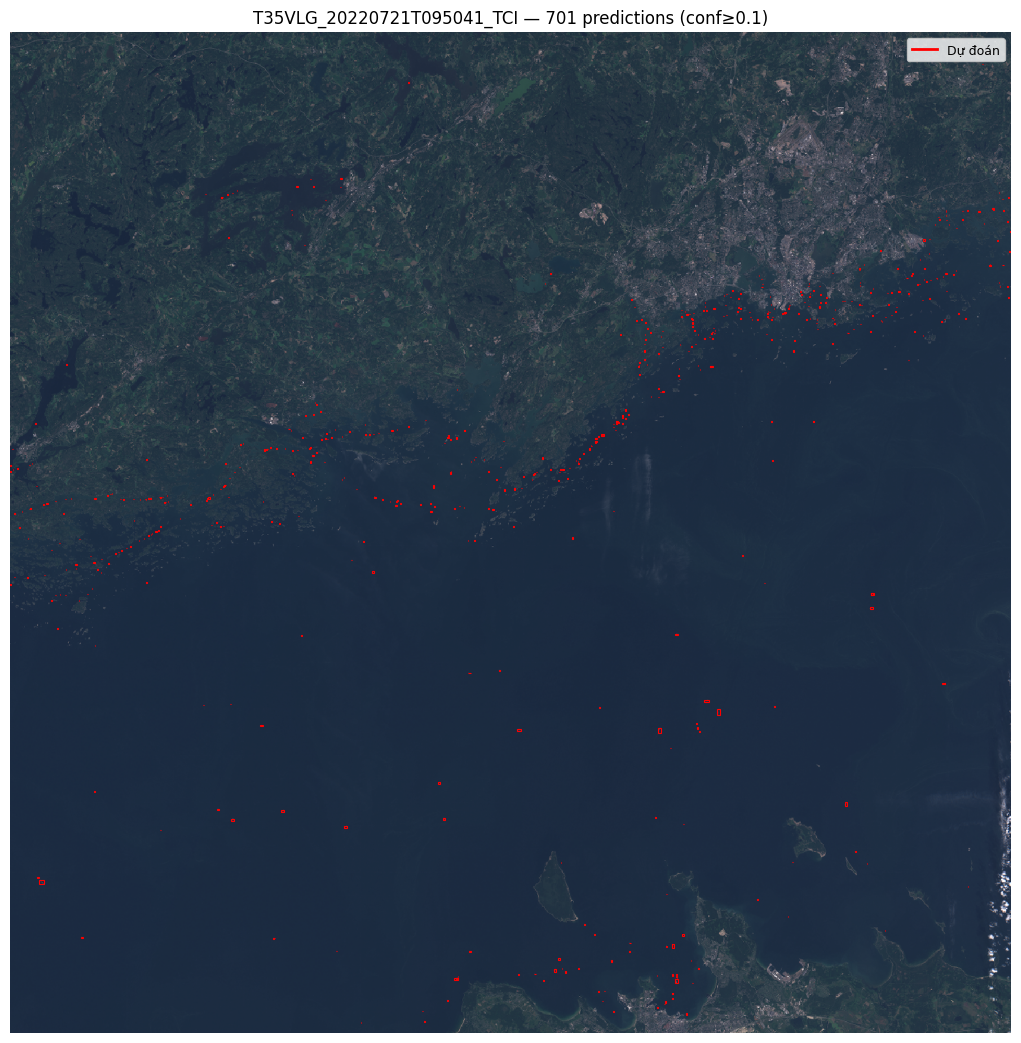

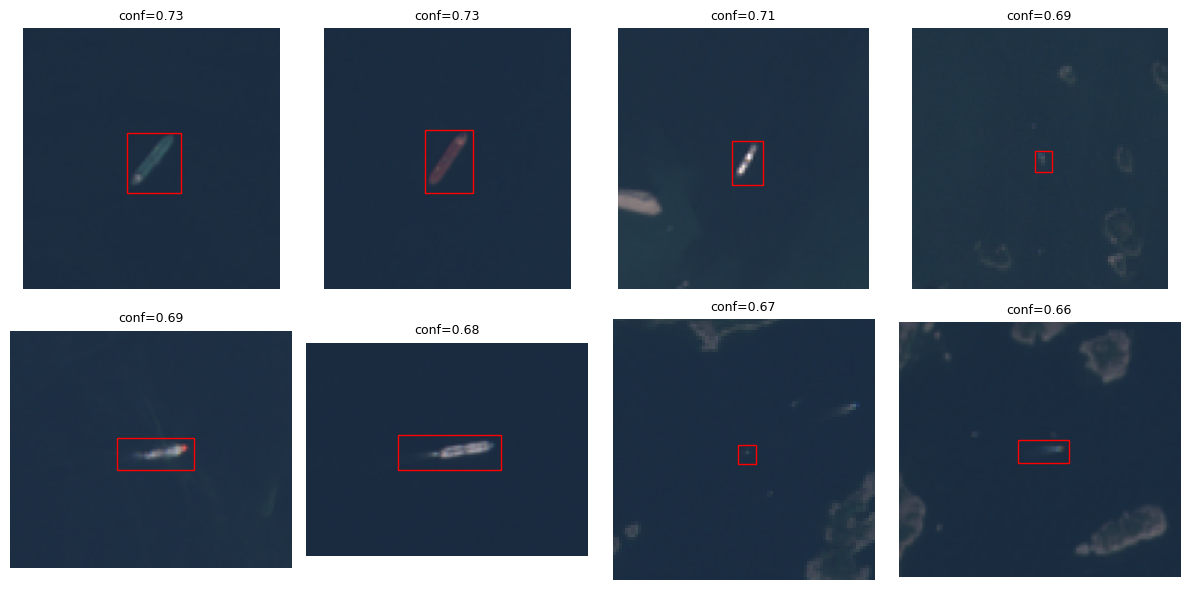


>>> T49PDQ_20260722T025529_TCI.jp2
Image info: 10980×10980px, 3 band -> 43×43 = 1849 tile (tile=320, overlap=64, imgsz=320).
Found 1849 tile above dark threshold
Vector gpkg /kaggle/working/drive_infer/T49PDQ_20260722T025529_TCI_pred.gpkg
Geojson  /kaggle/working/drive_infer/T49PDQ_20260722T025529_TCI_pred.geojson
Written to: /kaggle/working/drive_infer/T49PDQ_20260722T025529_TCI_annotated.tif


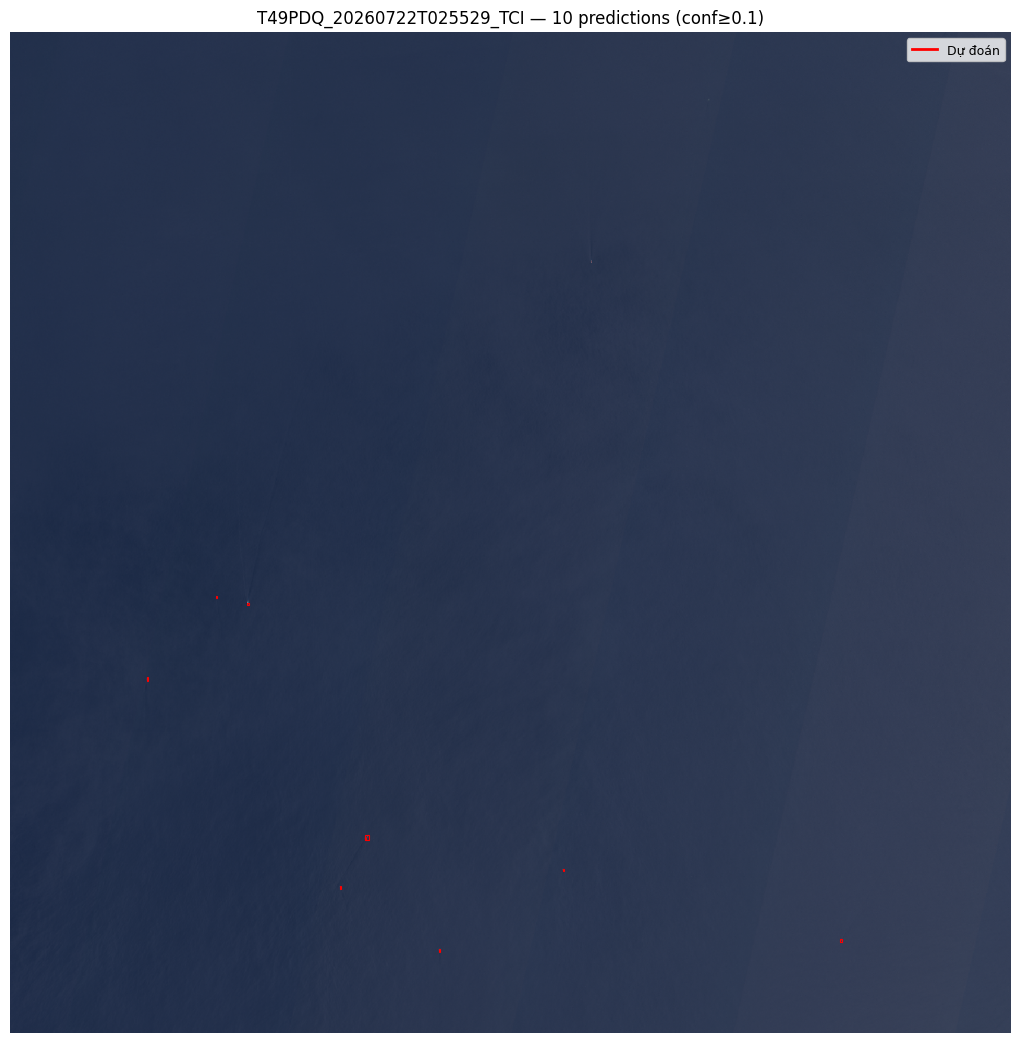

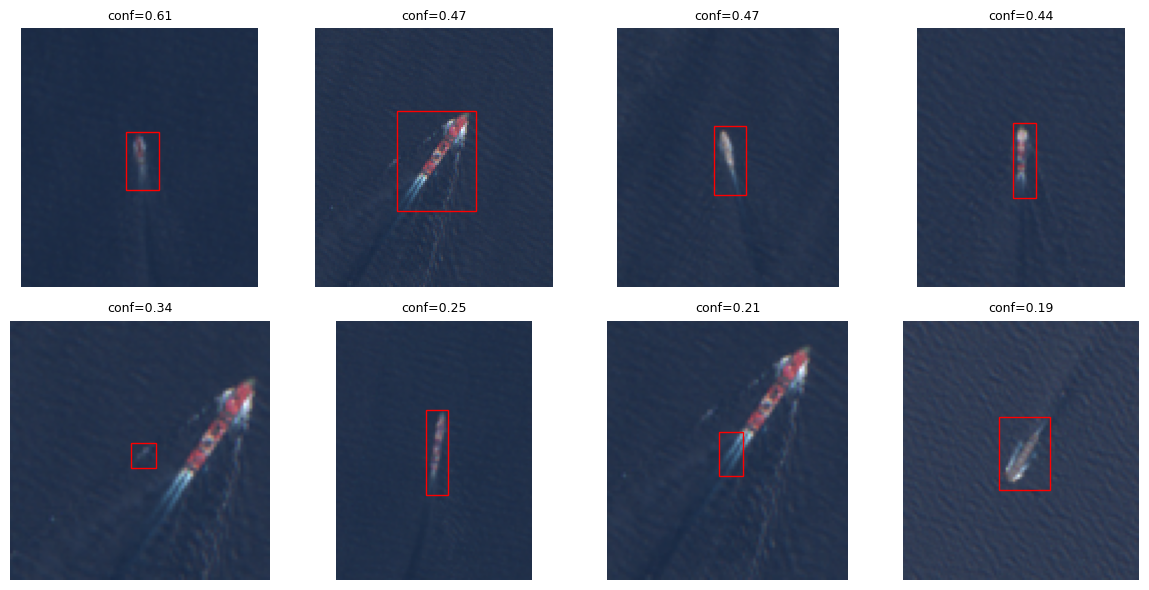


SUMMARY


,file,num_ships,num_gt,labeled,mode,size_MB
0,T35VLG_20220721T095041_TCI.jp2,701,None,False,pred,110.7
1,T49PDQ_20260722T025529_TCI.jp2,10,None,False,pred,135.3


Result saved at: /kaggle/working/drive_infer


In [7]:
import pandas as pd
from IPython.display import display


def _effective_mode():
    if not CFG.get("DRAW_GT", False):
        return "pred"
    m = str(CFG.get("EXPORT_MODE", "both")).lower()
    if m not in ("pred", "gt", "both"):
        print("Export mode not found")
        return "both"
    return m


def _gt_for(path):
    try:
        gt = gt_boxes_for_raster(path, CFG["GT_GPKG_PATH"], layer=CFG["GT_LAYER"], verbose=False)
    except FileNotFoundError:
        print("Not found ground truth, prediction only")
        return None
    except Exception as e:
        print("Ground truth error, skipping", str(e).splitlines()[0], ")")
        return None
    return gt


MODE = _effective_mode()

summary = []
for p in raster_files:
    stem = os.path.splitext(os.path.basename(p))[0]
    print("\n" + "=" * 70 + f"\n>>> {os.path.basename(p)}")
    try:
        b, s, (W, H) = infer_large_raster(
            p, model, conf=CFG["CONF"], tile=CFG["TILE"], overlap=CFG["OVERLAP"],
            imgsz=CFG["IMGSZ"], iou_nms=CFG["IOU_NMS"], nms_iou=CFG["NMS_IOU"],
            batch=CFG["BATCH"], skip_dark=CFG["SKIP_DARK"], device=DEVICE_EFF)
    except Exception as e:
        print("Inference error:", str(e).splitlines()[0])
        summary.append({"file": os.path.basename(p), "num_ships": None, "num_gt": None, "labeled": None, "mode": None, "size_MB": None})
        continue

    # ground truth if needed
    gt = _gt_for(p) if MODE in ("gt", "both") else None
    has_gt = gt is not None and len(gt) > 0
    file_mode = MODE if has_gt else "pred"
    draw_pred = file_mode in ("pred", "both")
    draw_gt = file_mode in ("gt", "both")

    # print(f"{len(b)} vessel with {CFG['CONF']} | {len(gt)} ground truth | export {file_mode}")

    pred_out = b if draw_pred else None
    gt_out = gt if draw_gt else None

    if draw_pred:
        save_detections_json(p, b, s, os.path.join(CFG["OUT_DIR"], f"{stem}_detections.json"))
    if draw_gt:
        save_gt_json(p, gt, os.path.join(CFG["OUT_DIR"], f"{stem}_gt.json"))

    if CFG["SAVE_VECTOR"]:
        if draw_pred:
            detections_to_vectors(p, b, s,
                                  out_geojson=os.path.join(CFG["OUT_DIR"], f"{stem}_pred.geojson"),
                                  out_gpkg=os.path.join(CFG["OUT_DIR"], f"{stem}_pred.gpkg"))
        if draw_gt:
            gt_to_vectors(p, gt,
                          out_geojson=os.path.join(CFG["OUT_DIR"], f"{stem}_gt.geojson"),
                          out_gpkg=os.path.join(CFG["OUT_DIR"], f"{stem}_gt.gpkg"))

    if CFG["SAVE_GEOTIFF"]:
        try:
            burn_boxes_to_raster(p, os.path.join(CFG["OUT_DIR"], f"{stem}_annotated.tif"),
                                 pred_out, s, gt_boxes=gt_out, driver="GTiff",
                                 thickness=CFG["LINE_THICKNESS"], max_megapixels=CFG["BURN_MAX_MP"])
        except Exception as e:
            print("GeoTIFF err:", str(e).splitlines()[0])
    if CFG["SAVE_JP2"]:
        try:
            burn_boxes_to_raster(p, os.path.join(CFG["OUT_DIR"], f"{stem}_annotated.jp2"),
                                 pred_out, s, gt_boxes=gt_out, driver="JP2OpenJPEG",
                                 thickness=CFG["LINE_THICKNESS"], jp2_quality=100,
                                 max_megapixels=CFG["BURN_MAX_MP"])
        except Exception as e:
            print("JP2 lỗi:", str(e).splitlines()[0])

    _parts = []
    if draw_pred:
        _parts.append(f"{len(b)} predictions (conf≥{CFG['CONF']})")
    if draw_gt:
        _parts.append(f"{len(gt)} GT")
    draw_overview(p, boxes=pred_out, gt_boxes=gt_out, max_side=CFG["OVERVIEW_MAX"], title=(f"{stem} — " + " · ".join(_parts)) if _parts else stem, save_path=os.path.join(CFG["OUT_DIR"], f"{stem}_overview.png"))
    if draw_pred and len(b):
        show_detection_crops(p, b, s, topk=8,
                             save_path=os.path.join(CFG["OUT_DIR"], f"{stem}_crops.png"))

    summary.append({"file": os.path.basename(p), "num_ships": int(len(b)),
                    "num_gt": (int(len(gt)) if has_gt else None),
                    "labeled": bool(has_gt), "mode": file_mode,
                    "size_MB": round(os.path.getsize(p) / 1e6, 1)})

print("\nSUMMARY")
df = pd.DataFrame(summary)
display(df)
df.to_csv(os.path.join(CFG["OUT_DIR"], "summary.csv"), index=False)
print("Result saved at:", CFG["OUT_DIR"])